# [9660] Homework 2 - Logistic Regression - Solution
Data file: https://raw.githubusercontent.com/vjavaly/Baruch-CIS-9660/main/data/mushrooms_1_30k.csv

## Homework Submission Rules (for all homework assignments)
* Homework is due by 6:30 PM on the due date
  * No late submission will be accepted
* Verify that you are submitting the correct homework file
* Homework file naming convention
  * LastName_FirstName_HwX.ipynb  [Replace X with the homework #]
    * 1 point deducted for submitting homework not complying with naming convention
* Before submission, execute "Kernel -> Restart Kernel and Run All Cells"
  * 1 point deducted for not submitting a cleanly executed notebook

## Homework 2 Requirements
* Load data into dataframe
* Examine data
* Prepare data for model training
  * Use SimpleImputer to replace missing values
  * Perform one-hot (dummy) encoding on categorical variable
  * Perform label encoding on target variable
* Train baseline Logistic Regression model
  * If you get errors, change appropriate hyperparameters to eliminate errors
  * Calculate and display model accuracy
  * Display confusion matrix
* Re-train Logistic Regression model to exceed accuracy of baseline model
  * Change hyperparameters accordingly to achieve this accuracy level
    * If you used hyperparameter random_state in your initial model training, do NOT change this value during model retrainings
    * Do NOT re-split training and test sets during model retrainings
  * Calculate and display accuracy of re-trained model
  * Display confusion matrix of re-trained model

In [ ]:
from datetime import datetime
print(f'Run time: {datetime.now().strftime("%D %T")}')

Run time: 09/25/24 15:04:52


### Import libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

### Load data

#### Mushrooms poisonous / edible dataset
Columns
* class  : target variable : string (poisonous, edible)
* cap-diameter : float (cm)
* stem-height : float (cm)
* stem-width : float (cm)
* season : string (spring, summer, autumn, winter)
* cap-shape : binary : one-hot encoded features for cap-shape
  * cap-shape_convex
  * cap-shape_flat
  * cap-shape_sunken
* cap-color : binary : one-hot encoded features for cap-color
  * cap-color_brown
  * cap-color_orange
  * cap-color_red
  * cap-color_white
  * cap-color_yellow
* habitat : binary : one-hot encoded features for habitat
  * habitat_grasses
  * habitat_heaths
  * habitat_leaves
  * habitat_meadows
  * habitat_woods
* mushroom-id : unique identifier : integer

In [ ]:
# Read data from file (mushrooms_1_30k.csv) into dataframe
#  NOTES:
#   Field separator is ';'
#   Use mushroom-id as the index column
df = pd.read_csv('https://raw.githubusercontent.com/vjavaly/Baruch-CIS-9660/main/data/mushrooms_1_30k.csv',
                sep=';', index_col='mushroom-id')

### Examine data

In [ ]:
pd.set_option('display.max_columns', None)

In [ ]:
# Review dataframe shape
df.shape

(30000, 18)

In [ ]:
# Display first few rows of dataframe
df.head()

,class,cap-diameter,stem-height,stem-width,season,cap-shape_convex,cap-shape_flat,cap-shape_sunken,cap-color_brown,cap-color_orange,cap-color_red,cap-color_white,cap-color_yellow,habitat_grasses,habitat_heaths,habitat_leaves,habitat_meadows,habitat_woods
mushroom-id,,,,,,,,,,,,,,,,,,
6899,poisonous,15.26,16.95,17.09,winter,1,0,0,0,1,0,0,0,0,0,0,0,1
9860,poisonous,16.60,17.99,18.19,summer,1,0,0,0,1,0,0,0,0,0,0,0,1
2436,poisonous,14.07,17.80,17.74,winter,1,0,0,0,1,0,0,0,0,0,0,0,1
9247,poisonous,14.17,15.77,15.98,winter,0,1,0,0,0,1,0,0,0,0,0,0,1
23440,poisonous,14.64,16.53,17.20,NaN,1,0,0,0,1,0,0,0,0,0,0,0,1


In [ ]:
# Display distribution counts for target variable 'class'
df['class'].value_counts()

,count
class,
poisonous,16404
edible,13596


### Prepare data

#### Check for missing values

In [ ]:
df.isnull().sum()

,0
class,0
cap-diameter,195
stem-height,0
stem-width,0
season,329
cap-shape_convex,0
cap-shape_flat,0
cap-shape_sunken,0
cap-color_brown,0
cap-color_orange,0


#### Use the SimpleImputer to replace missing values

In [ ]:
cols_to_impute_1 = ['cap-diameter']

In [ ]:
imp_mean = SimpleImputer(missing_values=np.nan, strategy='mean')

In [ ]:
df[cols_to_impute_1] = imp_mean.fit_transform(df[cols_to_impute_1])

In [ ]:
imp_most_freq = SimpleImputer(missing_values=np.nan, strategy='most_frequent')

In [ ]:
cols_to_impute_2 = ['season']

In [ ]:
df[cols_to_impute_2] = imp_most_freq.fit_transform(df[cols_to_impute_2])

#### Check for missing values again

In [ ]:
df.isnull().sum()

,0
class,0
cap-diameter,0
stem-height,0
stem-width,0
season,0
cap-shape_convex,0
cap-shape_flat,0
cap-shape_sunken,0
cap-color_brown,0
cap-color_orange,0


### Review updated dataframe

In [ ]:
df.head()

,class,cap-diameter,stem-height,stem-width,season,cap-shape_convex,cap-shape_flat,cap-shape_sunken,cap-color_brown,cap-color_orange,cap-color_red,cap-color_white,cap-color_yellow,habitat_grasses,habitat_heaths,habitat_leaves,habitat_meadows,habitat_woods
mushroom-id,,,,,,,,,,,,,,,,,,
6899,poisonous,15.26,16.95,17.09,winter,1,0,0,0,1,0,0,0,0,0,0,0,1
9860,poisonous,16.60,17.99,18.19,summer,1,0,0,0,1,0,0,0,0,0,0,0,1
2436,poisonous,14.07,17.80,17.74,winter,1,0,0,0,1,0,0,0,0,0,0,0,1
9247,poisonous,14.17,15.77,15.98,winter,0,1,0,0,0,1,0,0,0,0,0,0,1
23440,poisonous,14.64,16.53,17.20,autumn,1,0,0,0,1,0,0,0,0,0,0,0,1


#### One-hot (dummy) encode categorical variable 'season'

In [ ]:
df = pd.get_dummies(df, columns=['season'], dtype=int)
df.head()

,class,cap-diameter,stem-height,stem-width,cap-shape_convex,cap-shape_flat,cap-shape_sunken,cap-color_brown,cap-color_orange,cap-color_red,cap-color_white,cap-color_yellow,habitat_grasses,habitat_heaths,habitat_leaves,habitat_meadows,habitat_woods,season_autumn,season_spring,season_summer,season_winter
mushroom-id,,,,,,,,,,,,,,,,,,,,,
6899,poisonous,15.26,16.95,17.09,1,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,1
9860,poisonous,16.60,17.99,18.19,1,0,0,0,1,0,0,0,0,0,0,0,1,0,0,1,0
2436,poisonous,14.07,17.80,17.74,1,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,1
9247,poisonous,14.17,15.77,15.98,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,1
23440,poisonous,14.64,16.53,17.20,1,0,0,0,1,0,0,0,0,0,0,0,1,1,0,0,0


#### Label encode target variable 'class'

In [ ]:
le = LabelEncoder()
df['class']= le.fit_transform(df['class'])

In [ ]:
le.classes_

array(['edible', 'poisonous'], dtype=object)

In [ ]:
le.transform(list(le.classes_))

array([0, 1])

### Display first few rows of final updated dataframe before model training

In [ ]:
df.head()

,class,cap-diameter,stem-height,stem-width,cap-shape_convex,cap-shape_flat,cap-shape_sunken,cap-color_brown,cap-color_orange,cap-color_red,cap-color_white,cap-color_yellow,habitat_grasses,habitat_heaths,habitat_leaves,habitat_meadows,habitat_woods,season_autumn,season_spring,season_summer,season_winter
mushroom-id,,,,,,,,,,,,,,,,,,,,,
6899,1,15.26,16.95,17.09,1,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,1
9860,1,16.60,17.99,18.19,1,0,0,0,1,0,0,0,0,0,0,0,1,0,0,1,0
2436,1,14.07,17.80,17.74,1,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,1
9247,1,14.17,15.77,15.98,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,1
23440,1,14.64,16.53,17.20,1,0,0,0,1,0,0,0,0,0,0,0,1,1,0,0,0


### Separate independent and dependent variables
* Independent variables: All remaining variables except 'class'
* Dependent variable: 'class'

In [ ]:
X = df.drop("class", axis=1)
y = df["class"]

### Split data into training and test sets

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y,
                                                    test_size=0.25, random_state=42)

### Train Logistic Regression model

In [ ]:
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

### If the above results in error, review the error message, look up the documentation for LogisticRegression, change the appropriate model hyperparameter and re-train the model
* Repeat until there is no error

In [ ]:
model = LogisticRegression(max_iter=200)
model.fit(X_train, y_train)

LogisticRegression(max_iter=200)

### Test model

In [ ]:
# Generate predictions against the test set
predictions = model.predict(X_test)

In [ ]:
cnf_matrix = confusion_matrix(y_test, predictions)

### Model evaluation

In [ ]:
# Print model accuracy
accuracy = model.score(X_test, y_test)
print("accuracy = ", round((accuracy * 100), 5), "%")

accuracy =  65.88 %


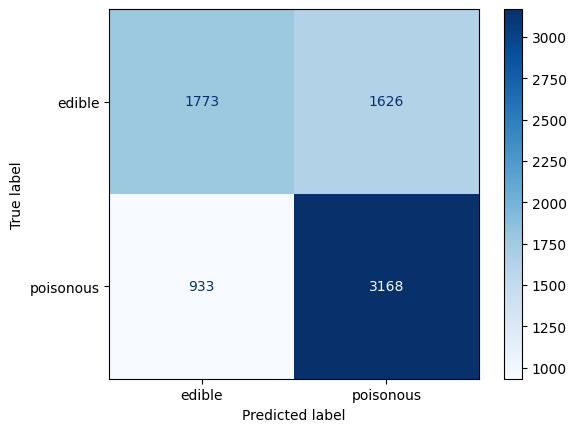

In [ ]:
# Display confusion matrix with class labels
disp = ConfusionMatrixDisplay(confusion_matrix=cnf_matrix,
                              display_labels=['edible', 'poisonous'])
disp.plot(cmap=plt.cm.Blues)
plt.show()

### Re-train logistic regression model with different hyperparameters
Goal: Improve model performance accuracy to exceed that of baseline model

In [ ]:
# Re-train model with different hyperparameters
model = LogisticRegression(penalty='l1', solver='liblinear')
model.fit(X_train, y_train)

LogisticRegression(penalty='l1', solver='liblinear')

### Test updated model

In [ ]:
# Generate predictions against the test set
predictions = model.predict(X_test)

### Evaluate updated model

In [ ]:
# Print updated model accuracy
accuracy = model.score(X_test, y_test)
print("accuracy = ", round((accuracy * 100), 5), "%")

accuracy =  65.92 %


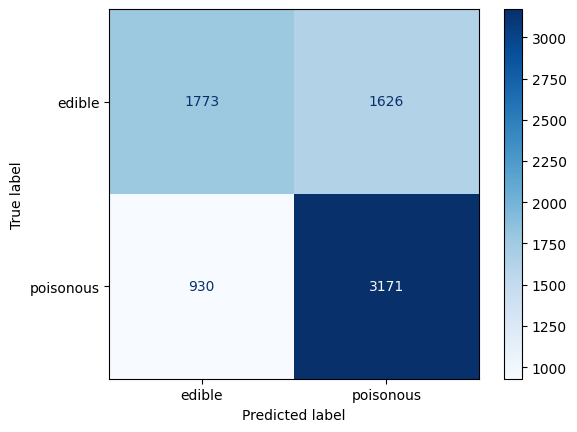

In [ ]:
# Display updated confusion matrix with class labels
cnf_matrix = confusion_matrix(y_test, predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cnf_matrix,
                              display_labels=['edible', 'poisonous'])
disp.plot(cmap=plt.cm.Blues)
plt.show()